In [2]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')
from keras.preprocessing.image import load_img

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D,MaxPooling2D,Input
from PIL import Image
from tensorflow.keras.utils import plot_model
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.initializers import random_uniform,glorot_uniform,constant,identity

In [4]:
from tensorflow.keras.layers import Dropout, Input, Add, Dense, Activation, BatchNormalization, Flatten, Conv2D, MaxPooling2D, GlobalMaxPooling2D
from tensorflow.keras.models import Model, load_model
import warnings
warnings.filterwarnings("ignore", message=".*CuDNN.*")
warnings.filterwarnings("ignore", message=".*cuFFT.*")
warnings.filterwarnings("ignore", message=".*cuBLAS.*")
import os
# from tensorflow.keras.utils import np_utils
from tensorflow.keras import utils
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import datasets, layers, models
from PIL import Image

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Path to dataset files: /kaggle/input/utkface-new


In [6]:

image_paths = []
age_labels = []
gender_paths = []

# 'path' is the root directory of the downloaded dataset.
# The actual images are in a subdirectory named 'UTKFace'.
images_base_path = os.path.join(path, 'UTKFace')

# Check if the images_base_path directory exists
if not os.path.isdir(images_base_path):
    print(f"Error: The image directory '{images_base_path}' was not found.")
    print("Please ensure the 'UTKFace' subdirectory exists within the downloaded dataset.")
else:
    for filename in tqdm(os.listdir(images_base_path)):
        temp = filename.split('_')
        if len(temp) >= 2 and temp[0].isdigit():  # Check if the first part of the filename is a number and filename format is correct
            age = int(temp[0])
            gender = int(temp[1])
            image_path = os.path.join(images_base_path, filename) # Correctly join the base path with filename
            image_paths.append(image_path)
            age_labels.append(age)
            gender_paths.append(gender)
        # else: # Optional: print filenames that don't match the pattern to help debug
        #     print(f"Skipping file due to incorrect format: {filename}")

100%|██████████| 23708/23708 [00:00<00:00, 462393.09it/s]


In [7]:
df=pd.DataFrame()
df['image_paths']=image_paths
df['age_labels']=age_labels
df['gender_paths']=gender_paths
df.head()

,image_paths,age_labels,gender_paths
0,/kaggle/input/utkface-new/UTKFace/26_0_2_20170...,26,0
1,/kaggle/input/utkface-new/UTKFace/22_1_1_20170...,22,1
2,/kaggle/input/utkface-new/UTKFace/21_1_3_20170...,21,1
3,/kaggle/input/utkface-new/UTKFace/28_0_0_20170...,28,0
4,/kaggle/input/utkface-new/UTKFace/17_1_4_20170...,17,1


In [8]:
print(f'DataFrame shape:{df.shape}')

DataFrame shape:(23708, 3)


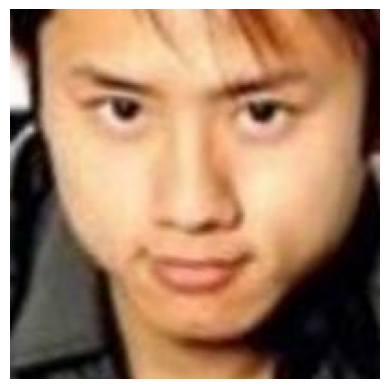

In [9]:
if not df.empty:
    gender_dict = {0: 'Male', 1: 'Female'}

    try:
        img = Image.open(df['image_paths'][0]) # Corrected column name to 'image_paths'
        plt.axis('off')
        plt.imshow(img)
        plt.show()
    except Exception as e:
        print(f"Error opening image: {e}")
else:
    print("Dataframe is empty. No images found.")

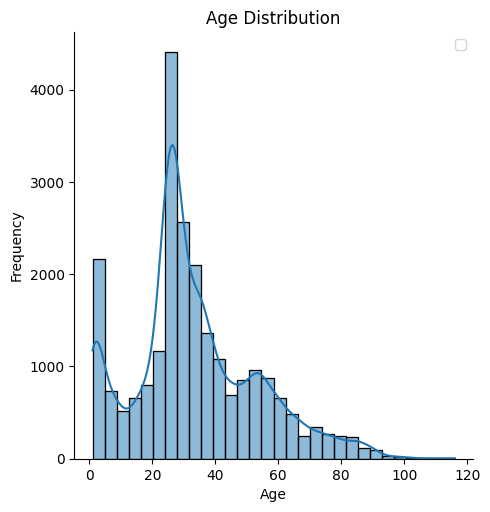

In [10]:
if not df.empty:
    sns.displot(df['age_labels'], kde=True, bins=30)
    plt.title('Age Distribution')
    plt.legend()
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.show()
else:
    print("DataFrame is empty. Please ensure the dataset is loaded correctly in previous steps and check the image path.")

In [11]:
def extract_feature(images):
    features =[]
    for image in tqdm(images):
        img = Image.open(image).convert('L')
        img=img.resize((128,128), Image.BILINEAR)
        img=np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features),128,128,1)
    return features

In [12]:
x=extract_feature(df['image_paths'])
print(f"x_shape:\t{x.shape}")

100%|██████████| 23708/23708 [01:34<00:00, 250.31it/s]


x_shape:	(23708, 128, 128, 1)


In [13]:
x=x/255.0
y_gender=np.array(df['gender_paths'])
y_age=np.array(df['age_labels'])
print("shape of y_gender:",y_gender.shape)
print("shape of y_age:",y_age.shape)

shape of y_gender: (23708,)
shape of y_age: (23708,)


In [14]:
from flax.typing import Out
input_shape=(128,128,1)
inputs=Input(shape=input_shape)

#convolutional Layer
conv1=Conv2D(32, kernel_size=(3,3), activation='relu')(inputs)
max1=MaxPooling2D(pool_size=(2,2))(conv1)

conv2=Conv2D(64, kernel_size=(3,3), activation='relu')(max1)
max2=MaxPooling2D(pool_size=(2,2))(conv2)

conv3=Conv2D(128, kernel_size=(3,3), activation='relu')(max2)
max3=MaxPooling2D(pool_size=(2,2))(conv3)

conv4=Conv2D(256, kernel_size=(3,3), activation='relu')(max3)
max4=MaxPooling2D(pool_size=(2,2))(conv4)

flatten=Flatten()(max4)

#fully connected layer
dense1=Dense(256, activation='relu')(flatten)
dense2=Dense(256, activation='relu')(flatten)

#dropout
drop1=Dropout(0.3)(dense1)
drop2=Dropout(0.3)(dense2)

#output layer
Output1=Dense(1, activation='sigmoid', name='gender_output')(drop1)
Output2=Dense(1, activation='linear', name='age_output')(drop2)

model=Model(inputs=inputs, outputs=[Output1, Output2])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 12, 12,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 6, 6, 256) │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 9216)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  2,359,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │  2,359,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │        257 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,107,458 (19.48 MB)

 Trainable params: 5,107,458 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
y_combined = np.stack((y_gender,y_age), axis=1)

#splitting the dataset into train test
X_train, X_temp, y_combined_train, y_combined_test = train_test_split(x, y_combined, test_size=0.2, random_state=42)

x_test,x_val,y_test,y_val=train_test_split(X_temp, y_combined_test, test_size=0.5, random_state=42)

#split y_combined back to y_gender and y_age
y_train_gender,y_train_age=y_combined_train[:,0], y_combined_train[:,1]
y_test_gender,y_test_age=y_combined_test[:,0], y_combined_test[:,1]
y_val_gender,y_val_age=y_val[:,0], y_val[:,1]

In [16]:
from keras.callbacks import LearningRateScheduler
model_path='./best_model.keras'

checkpointer= ModelCheckpoint(
    filepath=model_path,
    monitor='val_gender_output_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

model.compile(loss=['binary_crossentropy', 'mae'],
              optimizer='adam',
              metrics=['accuracy', 'mae'])
annealer=LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x)

In [17]:
total_images = len(image_paths)
print(f"Total number of images: {total_images}")

# Compute number of images in each set
train_images = len(X_train)
validation_images = len(x_val)
test_images = len(x_test)

print(f"Number of training images: {train_images}")
print(f"Number of validation images: {validation_images}")
print(f"Number of test images: {test_images}")

Total number of images: 23708
Number of training images: 18966
Number of validation images: 2371
Number of test images: 2371


In [18]:
import tensorflow as tf

tf.config.run_functions_eagerly(True)

#Training Model
history=model.fit(x=X_train,y=[y_train_gender,y_train_age],batch_size=128,epochs=100,validation_data=(x_val,[y_val_gender,y_val_age]),callbacks=[checkpointer,annealer])

Epoch 1/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - age_output_loss: 18.8398 - age_output_mae: 18.8398 - gender_output_accuracy: 0.5282 - gender_output_loss: 0.7556 - loss: 19.5953
Epoch 1: val_gender_output_accuracy improved from None to 0.53606, saving model to ./best_model.keras

Epoch 1: finished saving model to ./best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 38s 209ms/step - age_output_loss: 16.4564 - age_output_mae: 16.4564 - gender_output_accuracy: 0.5326 - gender_output_loss: 0.7118 - loss: 17.1683 - val_age_output_loss: 14.5394 - val_age_output_mae: 14.5394 - val_gender_output_accuracy: 0.5361 - val_gender_output_loss: 0.6846 - val_loss: 15.2240 - learning_rate: 0.0010
Epoch 2/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - age_output_loss: 14.2626 - age_output_mae: 14.2626 - gender_output_accuracy: 0.6288 - gender_output_loss: 0.6402 - loss: 14.9028
Epoch 2: val_gender_output_accuracy improved from 0.53606 to 0.74483, saving model to ./best_model.keras

Epoch 2: finishe

In [21]:
acc=history.history['gender_output_accuracy']
val_acc = history.history['val_gender_output_accuracy']
epochs = range(len(acc))

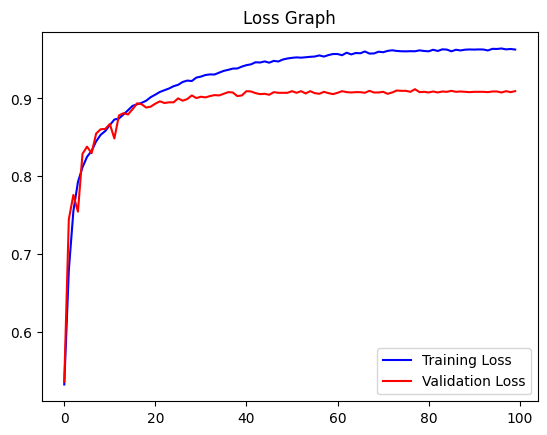

In [23]:
acc = history.history['gender_output_accuracy']
val_acc = history.history['val_gender_output_accuracy']
epochs = range(len(acc))
plt.plot(epochs, acc, 'b', label='Training Loss')
plt.plot(epochs, val_acc, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

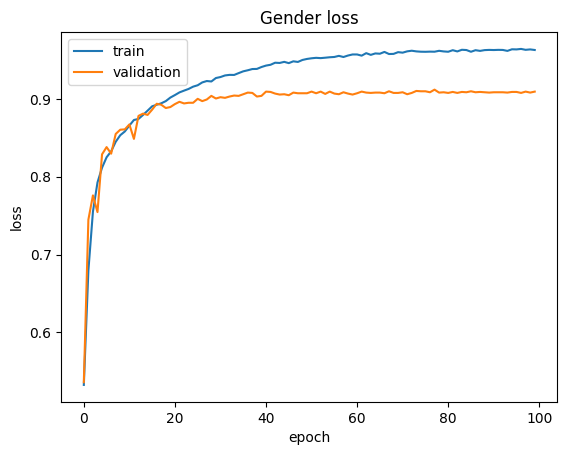

In [24]:
plt.plot(history.history['gender_output_accuracy'])
plt.plot(history.history['val_gender_output_accuracy'])
plt.title('Gender loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

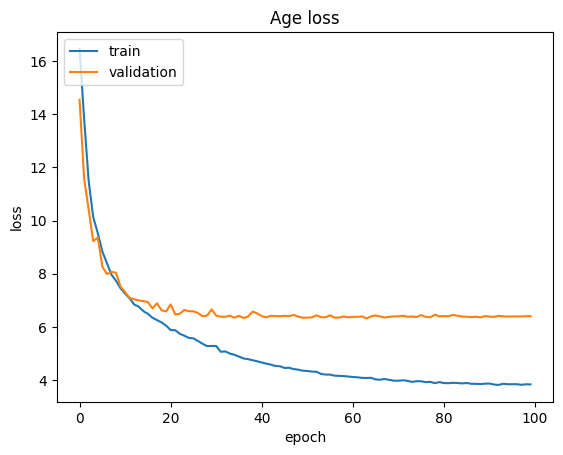

In [25]:
plt.plot(history.history['age_output_mae'])
plt.plot(history.history['val_age_output_mae'])
plt.title('Age loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Original Gender: 	Male 	 Original Age: 	28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
Predicted Gender: 	Male	 Predicted Age 	27


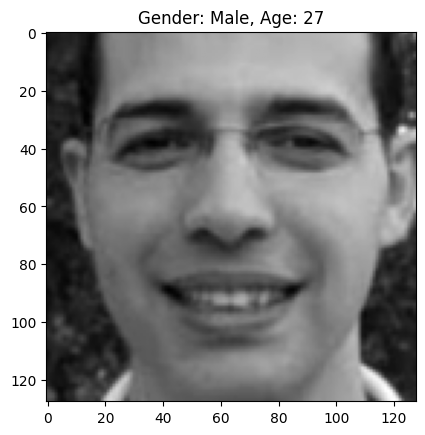

In [27]:
image_index = 3000
print(f"Original Gender: \t{gender_dict[y_gender[image_index]]} \t Original Age: \t{y_age[image_index]}")

pred = model.predict(x[image_index].reshape(1,128,128,1))
pred_gender = gender_dict[int(round(pred[0][0][0]))]
pred_age = round(pred[1][0][0])
print(f"Predicted Gender: \t{pred_gender}\t Predicted Age \t{pred_age}")
plt.title(f'Gender: {pred_gender}, Age: {pred_age}')
plt.imshow(x[image_index].reshape(128,128), cmap='gray')
plt.show()

Original Gender: 	Male 	 Original Age: 	37
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Predicted Gender: 	Male	 Predicted Age 	42


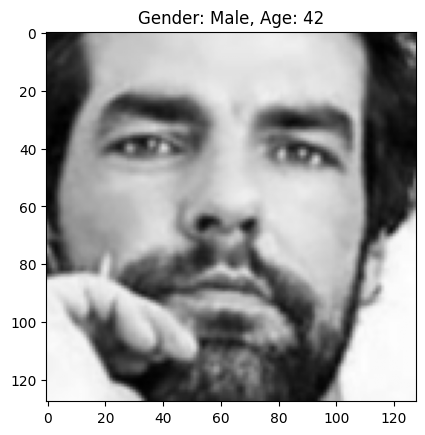

In [29]:
image_index = 133
print(f"Original Gender: \t{gender_dict[y_gender[image_index]]} \t Original Age: \t{y_age[image_index]}")

pred = model.predict(x[image_index].reshape(1,128,128,1))
pred_gender = gender_dict[int(round(pred[0][0][0]))]
pred_age = round(pred[1][0][0])
print(f"Predicted Gender: \t{pred_gender}\t Predicted Age \t{pred_age}")
plt.title(f'Gender: {pred_gender}, Age: {pred_age}')
plt.imshow(x[image_index].reshape(128,128), cmap='gray')
plt.show()

Original Gender: 	Male 	 Original Age: 	4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Gender: 	Male	 Predicted Age 	4


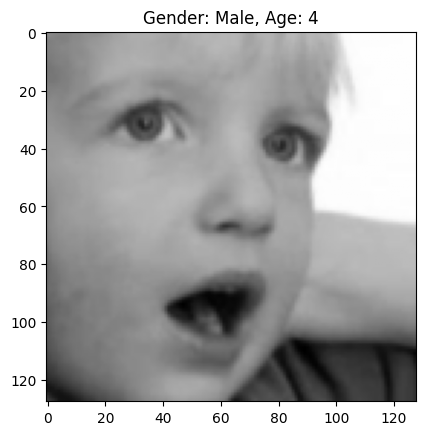

In [30]:
image_index = 22
print(f"Original Gender: \t{gender_dict[y_gender[image_index]]} \t Original Age: \t{y_age[image_index]}")

pred = model.predict(x[image_index].reshape(1,128,128,1))
pred_gender = gender_dict[int(round(pred[0][0][0]))]
pred_age = round(pred[1][0][0])
print(f"Predicted Gender: \t{pred_gender}\t Predicted Age \t{pred_age}")
plt.title(f'Gender: {pred_gender}, Age: {pred_age}')
plt.imshow(x[image_index].reshape(128,128), cmap='gray')
plt.show()